In [63]:
import numpy as np
import pandas as pd
import time
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns



In [64]:
model = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [65]:
data = [
    {"instruction": "pick the red block",                             "type": "pick"},
    {"instruction": "grab the blue cube",                             "type": "pick"},
    {"instruction": "lift the green sphere",                          "type": "pick"},
    {"instruction": "take the red ball from the shelf",               "type": "pick"},
    {"instruction": "get the small red cube",                         "type": "pick"},
    {"instruction": "retrieve the blue block on the left",            "type": "pick"},
    {"instruction": "collect the green object near the wall",         "type": "pick"},
    {"instruction": "fetch the red sphere from the corner",           "type": "pick"},
    {"instruction": "can you pick up the red ball?",                  "type": "pick"},
    {"instruction": "please grab the blue sphere",                    "type": "pick"},
    {"instruction": "I need you to lift the green block",             "type": "pick"},
    {"instruction": "pick up the blue cube on the floor",             "type": "pick"},
    {"instruction": "take the green block from the table",            "type": "pick"},
    {"instruction": "grab the large green block",                     "type": "pick"},
    {"instruction": "lift the red sphere gently",                     "type": "pick"},
    {"instruction": "get me the blue object near the edge",           "type": "pick"},
    {"instruction": "grab whichever block is blue",                   "type": "pick"},
    {"instruction": "pick the large red object",                      "type": "pick"},
    {"instruction": "lift the green ball near the wall",              "type": "pick"},
    {"instruction": "take the blue block on the left",                "type": "pick"},
    {"instruction": "grab the red cube carefully",                    "type": "pick"},
    {"instruction": "pick the blue object on the right",              "type": "pick"},
    {"instruction": "lift the small green sphere",                    "type": "pick"},
    {"instruction": "get the green cube near the edge",               "type": "pick"},
    {"instruction": "pick up the small blue ball",                    "type": "pick"},

    {"instruction": "push the red block forward",                     "type": "push"},
    {"instruction": "slide the blue cube to the right",               "type": "push"},
    {"instruction": "shove the green sphere aside",                   "type": "push"},
    {"instruction": "nudge the red ball toward the wall",             "type": "push"},
    {"instruction": "knock the blue block to the left",               "type": "push"},
    {"instruction": "roll the green ball to the corner",              "type": "push"},
    {"instruction": "push the green sphere away",                     "type": "push"},
    {"instruction": "slide the blue sphere forward gently",           "type": "push"},
    {"instruction": "give the blue cube a gentle push",               "type": "push"},
    {"instruction": "shove the red sphere aside",                     "type": "push"},
    {"instruction": "push the red cube away from you",                "type": "push"},
    {"instruction": "slide the red ball to the left",                 "type": "push"},
    {"instruction": "push the large green block forward",             "type": "push"},
    {"instruction": "give the blue block a push",                     "type": "push"},
    {"instruction": "shove the green cube to the left",               "type": "push"},
    {"instruction": "slide the blue object to the right side",        "type": "push"},
    {"instruction": "push the green ball toward the edge",            "type": "push"},
    {"instruction": "push the small green cube aside",                "type": "push"},
    {"instruction": "push the red block to the right side",           "type": "push"},
    {"instruction": "shove the red object toward the wall",           "type": "push"},
    {"instruction": "slide the red object toward the box",            "type": "push"},
    {"instruction": "nudge the green block a little to the right",    "type": "push"},
    {"instruction": "roll the red ball away from the edge",           "type": "push"},
    {"instruction": "push the blue ball to the corner",               "type": "push"},
    {"instruction": "push the blue sphere gently forward",            "type": "push"},


    {"instruction": "move to the table",                              "type": "move"},
    {"instruction": "go to the left side",                            "type": "move"},
    {"instruction": "navigate to the right side",                     "type": "move"},
    {"instruction": "head to the center carefully",                   "type": "move"},
    {"instruction": "travel to the far end of the table",             "type": "move"},
    {"instruction": "approach the left corner",                       "type": "move"},
    {"instruction": "reposition yourself to the right side",          "type": "move"},
    {"instruction": "move the arm to home position",                  "type": "move"},
    {"instruction": "go to the center of the scene",                  "type": "move"},
    {"instruction": "move closer to the wall",                        "type": "move"},
    {"instruction": "head to the right side",                         "type": "move"},
    {"instruction": "navigate to the left corner",                    "type": "move"},
    {"instruction": "move toward the center",                         "type": "move"},
    {"instruction": "go to the far end",                              "type": "move"},
    {"instruction": "head toward the right corner",                   "type": "move"},
    {"instruction": "move to where the red block is",                 "type": "move"},
    {"instruction": "go near the blue object",                        "type": "move"},
    {"instruction": "move toward the box",                            "type": "move"},
    {"instruction": "go to the edge of the table",                    "type": "move"},
    {"instruction": "move to the near side",                          "type": "move"},
    {"instruction": "go to the left end of the table",                "type": "move"},
    {"instruction": "approach the table slowly",                      "type": "move"},
    {"instruction": "travel to the right end",                        "type": "move"},
    {"instruction": "reposition to the center of the workspace",      "type": "move"},
    {"instruction": "move the arm to the table",                      "type": "move"},


    {"instruction": "put the red block on the table",                 "type": "put"},
    {"instruction": "place the green cube to the left",               "type": "put"},
    {"instruction": "set the red ball on the shelf",                  "type": "put"},
    {"instruction": "drop the red cube on the table",                 "type": "put"},
    {"instruction": "lay the blue block flat on the surface",         "type": "put"},
    {"instruction": "rest the green sphere on the right side",        "type": "put"},
    {"instruction": "leave the red block near the edge",              "type": "put"},
    {"instruction": "deposit the blue cube on the left side",         "type": "put"},
    {"instruction": "put the blue object down carefully",             "type": "put"},
    {"instruction": "put the blue cube next to the wall",             "type": "put"},
    {"instruction": "place the green cube inside the container",      "type": "put"},
    {"instruction": "set the red block near the edge",                "type": "put"},
    {"instruction": "place the green cube to the left",               "type": "put"},
    {"instruction": "set the green sphere down gently",               "type": "put"},
    {"instruction": "set the red object down on the right",           "type": "put"},
    {"instruction": "put the small blue block on top",                "type": "put"},
    {"instruction": "put the blue sphere inside the box",             "type": "put"},
    {"instruction": "place the green block on the right side",        "type": "put"},
    {"instruction": "place the blue cube in the box",                 "type": "put"},
    {"instruction": "drop the red sphere on the left side",           "type": "put"},
    {"instruction": "drop the red object near the wall",              "type": "put"},
    {"instruction": "place the green object on the shelf",            "type": "put"},
    {"instruction": "put the blue block on the table please",         "type": "put"},
    {"instruction": "put the blue sphere on top of the box",          "type": "put"},
    {"instruction": "place the green sphere on the floor",            "type": "put"},

    {"instruction": "find the red block",                             "type": "find"},
    {"instruction": "locate the green ball near the edge",            "type": "find"},
    {"instruction": "look for the green sphere",                      "type": "find"},
    {"instruction": "search for the blue object",                     "type": "find"},
    {"instruction": "spot the red cube on the table",                 "type": "find"},
    {"instruction": "scan for the green block nearby",                "type": "find"},
    {"instruction": "identify the blue sphere in the scene",          "type": "find"},
    {"instruction": "detect the red object near the wall",            "type": "find"},
    {"instruction": "recognize the green cube on the left",           "type": "find"},
    {"instruction": "where is the blue cube?",                        "type": "find"},
    {"instruction": "where is the large green cube?",                 "type": "find"},
    {"instruction": "where is the small blue block?",                 "type": "find"},
    {"instruction": "can you locate the red ball?",                   "type": "find"},
    {"instruction": "can you find the blue cube?",                    "type": "find"},
    {"instruction": "can you spot the green sphere?",                 "type": "find"},
    {"instruction": "find the green object near the wall",            "type": "find"},
    {"instruction": "find the small blue sphere",                     "type": "find"},
    {"instruction": "find whichever object is green",                 "type": "find"},
    {"instruction": "look for the red block on the right",            "type": "find"},
    {"instruction": "look for the red sphere on the left",            "type": "find"},
    {"instruction": "search for the red cube on the floor",           "type": "find"},
    {"instruction": "search for the green block nearby",              "type": "find"},
    {"instruction": "find the blue object near the corner",           "type": "find"},
    {"instruction": "locate the red cube on the table",               "type": "find"},
    {"instruction": "locate the red object on the shelf",             "type": "find"},
    {"instruction": "scan the area for any objects",                  "type": "find"},
    {"instruction": "what objects can you see?",                      "type": "find"},
    {"instruction": "is there anything on the table?",                "type": "find"},

]

df = pd.DataFrame(data)


In [66]:
df = df.drop_duplicates(subset=["instruction"]).reset_index(drop=True)

print("\nClass distribution:")
print(df["type"].value_counts().to_string())


Class distribution:
type
find    28
pick    25
push    25
move    25
put     24


In [67]:
embeddings_np = model.encode(
    df["instruction"].tolist(),
    convert_to_tensor=False,
    show_progress_bar=True
)

df["embedding"] = list(embeddings_np)
X = embeddings_np 


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [68]:
df.to_pickle("nlp_instructions_124_with_embeddings.pkl")
df[["instruction","type"]].to_csv("nlp_instructions_145.csv", index=False)

print(f"   Matrix shape: {embeddings_np.shape}")
print(f"   Embedding dim: {embeddings_np.shape[1]} (expected 384)")
print(f"   Files saved: nlp_instructions_124.csv + .pkl")

   Matrix shape: (127, 384)
   Embedding dim: 384 (expected 384)
   Files saved: nlp_instructions_124.csv + .pkl


In [69]:
test_instruction = "pick the red block"

_ = model.encode([test_instruction])

times = []
for _ in range(20):
    t0 = time.time()
    emb = model.encode([test_instruction])
    times.append((time.time() - t0) * 1000)

avg_ms = np.mean(times)
status = " PASS" if avg_ms < 10 else "SLOW"

print(f"{status} — Avg encoding time: {avg_ms:.2f}ms (target: <10ms)")
print(f"   Embedding shape: {emb.shape}  (expected: (1, 384))")

SLOW — Avg encoding time: 26.11ms (target: <10ms)
   Embedding shape: (1, 384)  (expected: (1, 384))


In [ ]:
same_intent_pairs = [
    ("pick the red cube",                "grab the red cube"),
    ("lift the blue block",              "take the blue block"),
    ("get the green sphere",             "pick up the green sphere"),
    ("push the blue cube to the right",  "slide the blue cube to the right"),
    ("shove the red block forward",      "push the red block forward"),
    ("move to the left side",            "go to the left side"),
    ("head to the table",                "go to the table"),
    ("put the red block on the table",   "place the red block on the table"),
    ("set the blue cube down",           "put the blue cube down"),
    ("find the green sphere",            "look for the green sphere"),
    ("locate the blue cube",             "search for the blue cube"),
    ("where is the red block?",          "can you find the red block?"),
]

cross_class_pairs = [
    ("pick the red block",   "move to the table"),
    ("push the blue cube forward", "find the green sphere"),
    ("put the red block on the table", "go to the left side"),
    ("where is anything green?",  "push the red block forward"),]

SAME_THRESHOLD = 0.85
SOFT_THRESHOLD = 0.75 
CROSS_THRESHOLD = 0.50

print("SAME-INTENT pairs (target > 0.85)")
same_pass = 0
for a, b in same_intent_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    strict = sim >= SAME_THRESHOLD
    soft   = sim >= SOFT_THRESHOLD
    if strict:
        icon = "strict"
    elif soft:
        icon = "soft  "
    else:
        icon = "fail  "
    same_pass += strict
    print(f"  {icon} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {same_pass}/{len(same_intent_pairs)} passed threshold {SAME_THRESHOLD}")

print("CROSS-CLASS pairs (target < 0.50 — should be different)")
cross_pass = 0
for a, b in cross_class_pairs:
    ea, eb = model.encode([a])[0], model.encode([b])[0]
    sim = cosine_similarity([ea], [eb])[0][0]
    ok = sim < CROSS_THRESHOLD
    cross_pass += ok
    icon = "good" if ok else "not good "
    print(f"  {icon} {sim:.4f} | '{a}' ↔ '{b}'")

print(f"\nResult: {cross_pass}/{len(cross_class_pairs)} pairs correctly separated")

SAME-INTENT pairs (target > 0.85)
  strict 0.9031 | 'pick the red cube' ↔ 'grab the red cube'
  soft   0.7957 | 'lift the blue block' ↔ 'take the blue block'
  strict 0.8954 | 'get the green sphere' ↔ 'pick up the green sphere'
  strict 0.9529 | 'push the blue cube to the right' ↔ 'slide the blue cube to the right'
  strict 0.9047 | 'shove the red block forward' ↔ 'push the red block forward'
  soft   0.8135 | 'move to the left side' ↔ 'go to the left side'
  soft   0.7784 | 'head to the table' ↔ 'go to the table'
  strict 0.9867 | 'put the red block on the table' ↔ 'place the red block on the table'
  strict 0.9640 | 'set the blue cube down' ↔ 'put the blue cube down'
  soft   0.7962 | 'find the green sphere' ↔ 'look for the green sphere'
  strict 0.9264 | 'locate the blue cube' ↔ 'search for the blue cube'
  strict 0.8756 | 'where is the red block?' ↔ 'can you find the red block?'

Result: 0/12 passed threshold 0.85
CROSS-CLASS pairs (target < 0.50 — should be different)
  good 0.233

In [71]:
label_map = {"pick": 0, "push": 1, "move": 2, "put": 3, "find": 4}
labels = df["type"].map(label_map).values

sil_score = silhouette_score(X, labels)

sim_matrix = cosine_similarity(X)
intra_sims, inter_sims = [], []
types = df["type"].unique()

for t in types:
    idxs = df[df["type"] == t].index.tolist()
    other_idxs = df[df["type"] != t].index.tolist()

    intra = sim_matrix[np.ix_(idxs, idxs)]
    tri = np.triu_indices_from(intra, k=1)
    if len(tri[0]) > 0:
        intra_sims.append(np.mean(intra[tri]))

    inter = sim_matrix[np.ix_(idxs, other_idxs)]
    inter_sims.append(np.mean(inter))

avg_intra = np.mean(intra_sims)
avg_inter = np.mean(inter_sims)
ratio = avg_intra / avg_inter

clf = LogisticRegression(max_iter=1000, random_state=42)
scores = cross_val_score(clf, X, df["type"], cv=5)
accuracy = scores.mean() * 100

print("Per-class intra-class similarity:")
for t, s in zip(types, intra_sims):
    print(f"  {t:6s}: {s:.4f}")



def check(label, val, target, higher_better=True, fmt=".4f"):
    passed = val >= target if higher_better else val <= target
    icon = "good" if passed else "not good"
    print(f"  {icon} {label}: {val:{fmt}}  (target: {'>' if higher_better else '<'} {target})")

check("Silhouette score    ", sil_score,  0.12)
check("Avg intra similarity", avg_intra,  0.50)
check("Avg inter similarity", avg_inter,  0.45, higher_better=False)
check("Intra/Inter ratio   ", ratio,      1.30)
check("Classifier accuracy ", accuracy,   90.0, fmt=".1f")

Per-class intra-class similarity:
  pick  : 0.4574
  push  : 0.5281
  move  : 0.4315
  put   : 0.4982
  find  : 0.4321
  not good Silhouette score    : 0.0387  (target: > 0.12)
  not good Avg intra similarity: 0.4695  (target: > 0.5)
  good Avg inter similarity: 0.3562  (target: < 0.45)
  good Intra/Inter ratio   : 1.3179  (target: > 1.3)
  not good Classifier accuracy : 88.9  (target: > 90.0)


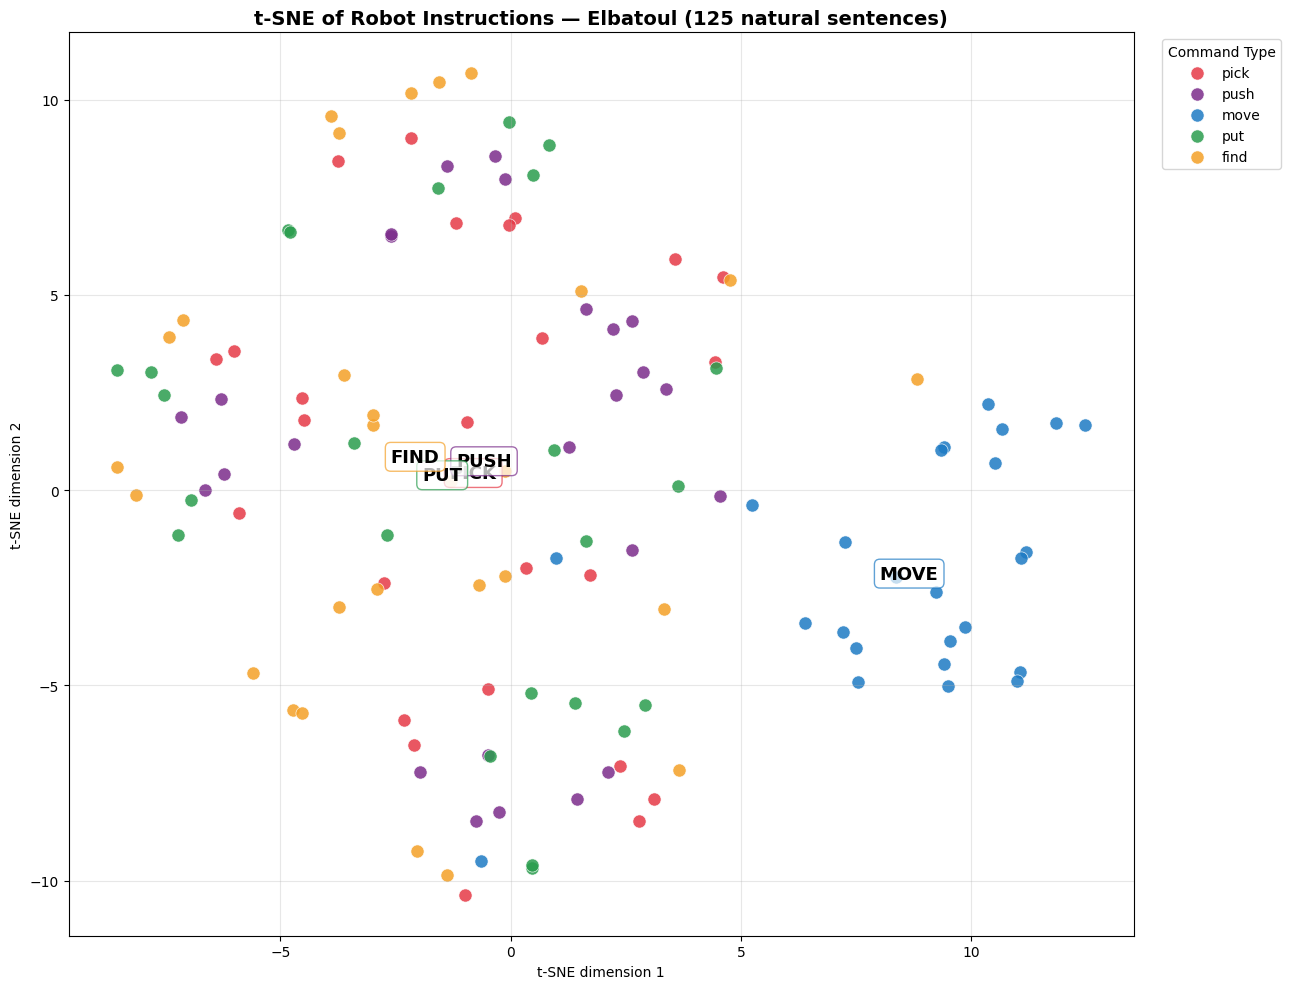

In [72]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X)

palette = {
    "pick": "#e63946",   
    "push": "#7b2d8b",   
    "move": "#1d7ac4",   
    "put":  "#2a9d4e",   
    "find": "#f4a027",  
}

fig, ax = plt.subplots(figsize=(13, 10))

for t, color in palette.items():
    mask = df["type"] == t
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=color, label=t, s=90, alpha=0.85, edgecolors='white', linewidths=0.5
    )

for t, color in palette.items():
    idxs = df[df["type"] == t].index
    cx, cy = X_2d[idxs, 0].mean(), X_2d[idxs, 1].mean()
    ax.text(cx, cy, t.upper(), fontsize=13, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor=color))

ax.set_title("t-SNE of Robot Instructions — Elbatoul (125 natural sentences)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(title="Command Type", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_elbatoul_v2.png", dpi=150, bbox_inches='tight')
plt.show()


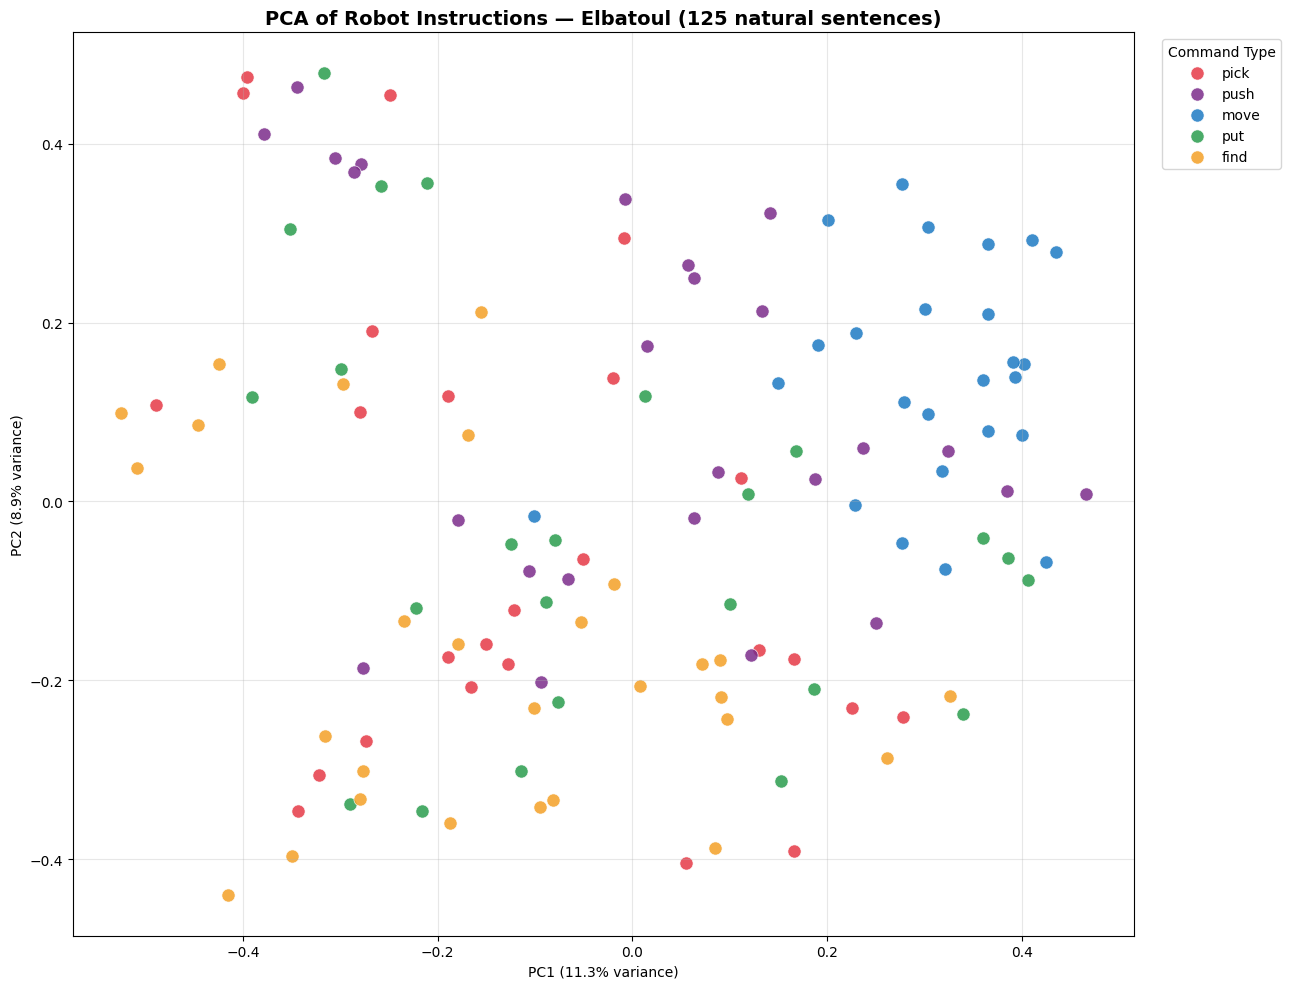

In [73]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(13, 10))

for t, color in palette.items():
    mask = df["type"] == t
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=t, s=90, alpha=0.85, edgecolors='white', linewidths=0.5
    )

ax.set_title("PCA of Robot Instructions — Elbatoul (125 natural sentences)",
             fontsize=14, fontweight='bold')
ax.set_xlabel(f"PC1 ({var1:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var2:.1f}% variance)")
ax.legend(title="Command Type", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_elbatoul_v2.png", dpi=150, bbox_inches='tight')
plt.show()